In [1]:
# Import libraries
import numpy as np
import pickle
import mne
import os
import ipywidgets as widgets
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline
# set size of raw browser
mne.utils.config.set_config('MNE_BROWSE_RAW_SIZE','16.0,8.0')

In [2]:
paths = [os.path.join("open_science_data", p) for p in os.listdir("open_science_data") if p.endswith(".gdf")]
print


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [3]:
data_dir = {}
for p in paths:
    tag = p[-7:-4]
    try:
        data_dir[tag] = mne.io.read_raw_gdf(p, preload=True)

    except:
        print(tag)
    




Extracting GDF parameters from open_science_data/V06.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
FP1, FP2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, P8, Fz, Cz, Pz, A1, A2, AFz, CPz, POz
Creating raw.info structure...
Reading 0 ... 369983  =      0.000 ...  1479.932 secs...
Extracting GDF parameters from open_science_data/V04.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
FP1, FP2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, P8, Fz, Cz, Pz, M1, M2, AFz, CPz, POz
Creating raw.info structure...
Reading 0 ... 369951  =      0.000 ...  1479.804 secs...
Extracting GDF parameters from open_science_data/V05.gdf...
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
FP1, FP2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, P8, Fz, Cz, Pz, A1, A2, A

In [30]:
from mne.preprocessing import annotate_muscle_zscore

raw = data_dir["V06"]

def preprocess_data(raw):
    # 1. Calculate 20 minutes directly in SECONDS (20 mins * 60 secs = 1200 seconds)
    t_max_seconds = 20 * 60 - 1
    
    # 2. Crop and OVERWRITE the local variable 'raw'
    raw = raw.copy().crop(tmax=t_max_seconds)

    # 3. Apply your case-insensitive 10-20 montage map
    raw.set_montage('standard_1020', match_case=False)

    annot_muscle, _ = annotate_muscle_zscore(
        raw, ch_type="eeg", threshold=5, min_length_good=0.2, filter_freq=[100, 120]  # Lowered to sit safely below your 125 Hz Nyquist ceiling!
    )
    
    raw.set_annotations(raw.annotations + annot_muscle)

    d1 = raw.copy().notch_filter(freqs=60).filter(l_freq=1, h_freq=40)

    return d1


v6 = preprocess_data(raw)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1e+02 - 1.2e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 100.00
- Lower transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 87.50 Hz)
- Upper passband edge: 120.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 122.50 Hz)
- Filter length: 165 samples (0.660 s)

Setting up low-pass filter at 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 413 samples (1.652 s)

Filtering raw data 

Fitting ICA to data using 24 channels (please be patient, this may take a while)
Omitting 6460 of 299751 (2.16%) samples, retaining 293291 (97.84%) samples.
Selecting by non-zero PCA components: 24 components
Fitting ICA took 3.3s.


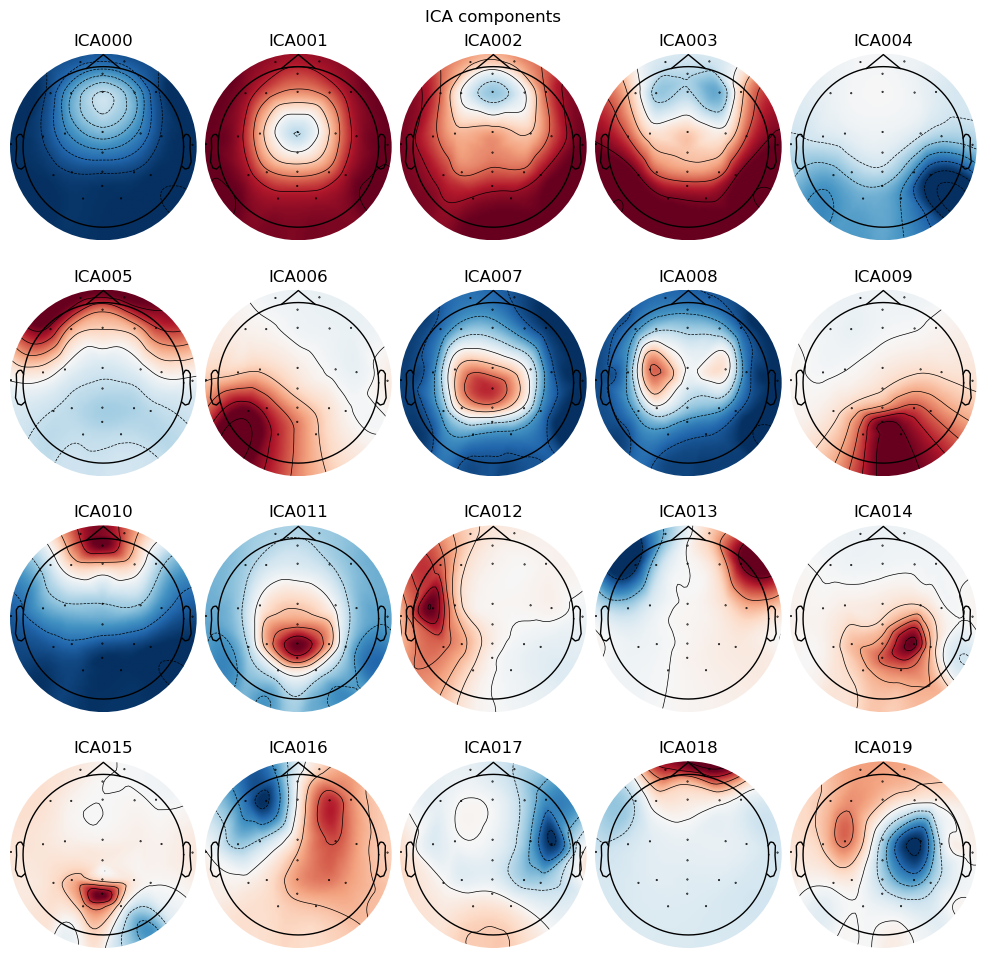

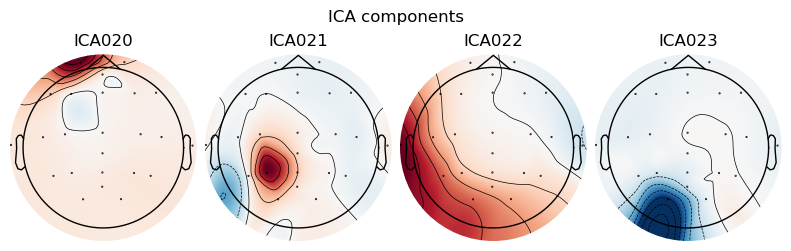

[<MNEFigure size 975x967 with 20 Axes>, <MNEFigure size 780x260.5 with 4 Axes>]

In [31]:
ica = mne.preprocessing.ICA()
ica.fit(v6.copy().pick('eeg'))
ica.plot_components()

Setting 11506 of 299751 (3.84%) samples to NaN, retaining 288245 (96.16%) samples.
Effective window size : 8.192 (s)
At least one good data span is shorter than n_per_seg, and will be analyzed with a shorter window than the rest of the file.
Plotting power spectral density (dB=True).


/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 738, using nperseg = 738
  return _func(*args, **kwargs)
/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 232, using nperseg = 232
  return _func(*args, **kwargs)
/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 711, using nperseg = 711
  return _func(*args, **kwargs)
/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048 is greater than input length  = 595, using nperseg = 595
  return _func(*args, **kwargs)
/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 2048

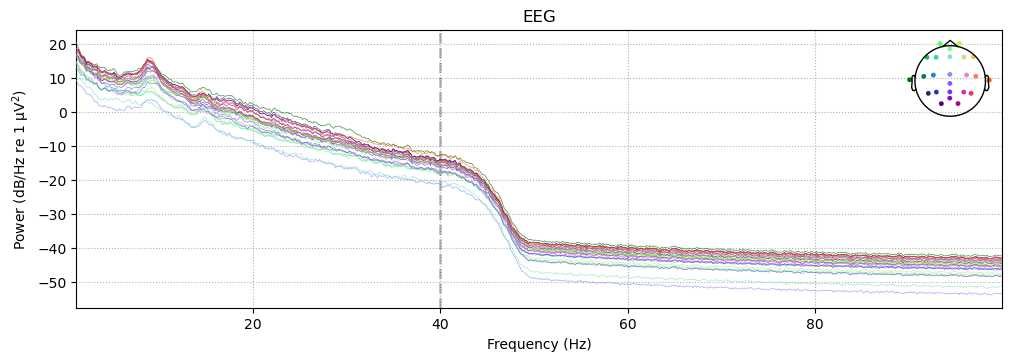

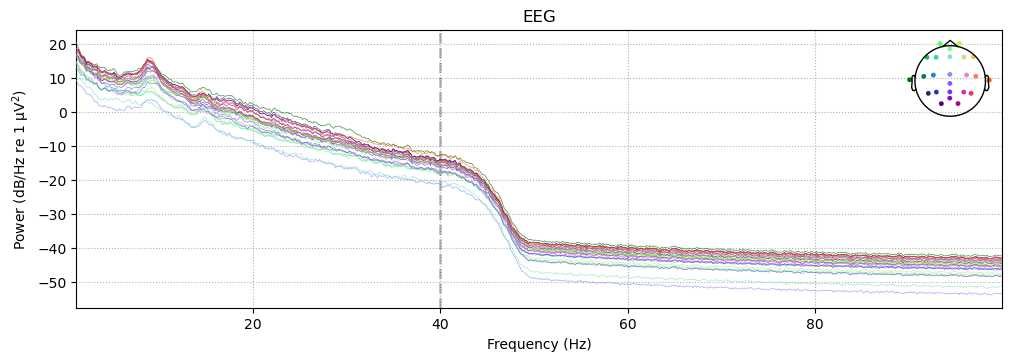

In [ ]:

# Plot the raw data's frequencies to check for power line noise
v.compute_psd(fmin=1, fmax=100).plot()

Creating RawArray with float64 data, n_channels=24, n_times=299751
    Range : 0 ... 299750 =      0.000 ...  1199.000 secs
Ready.


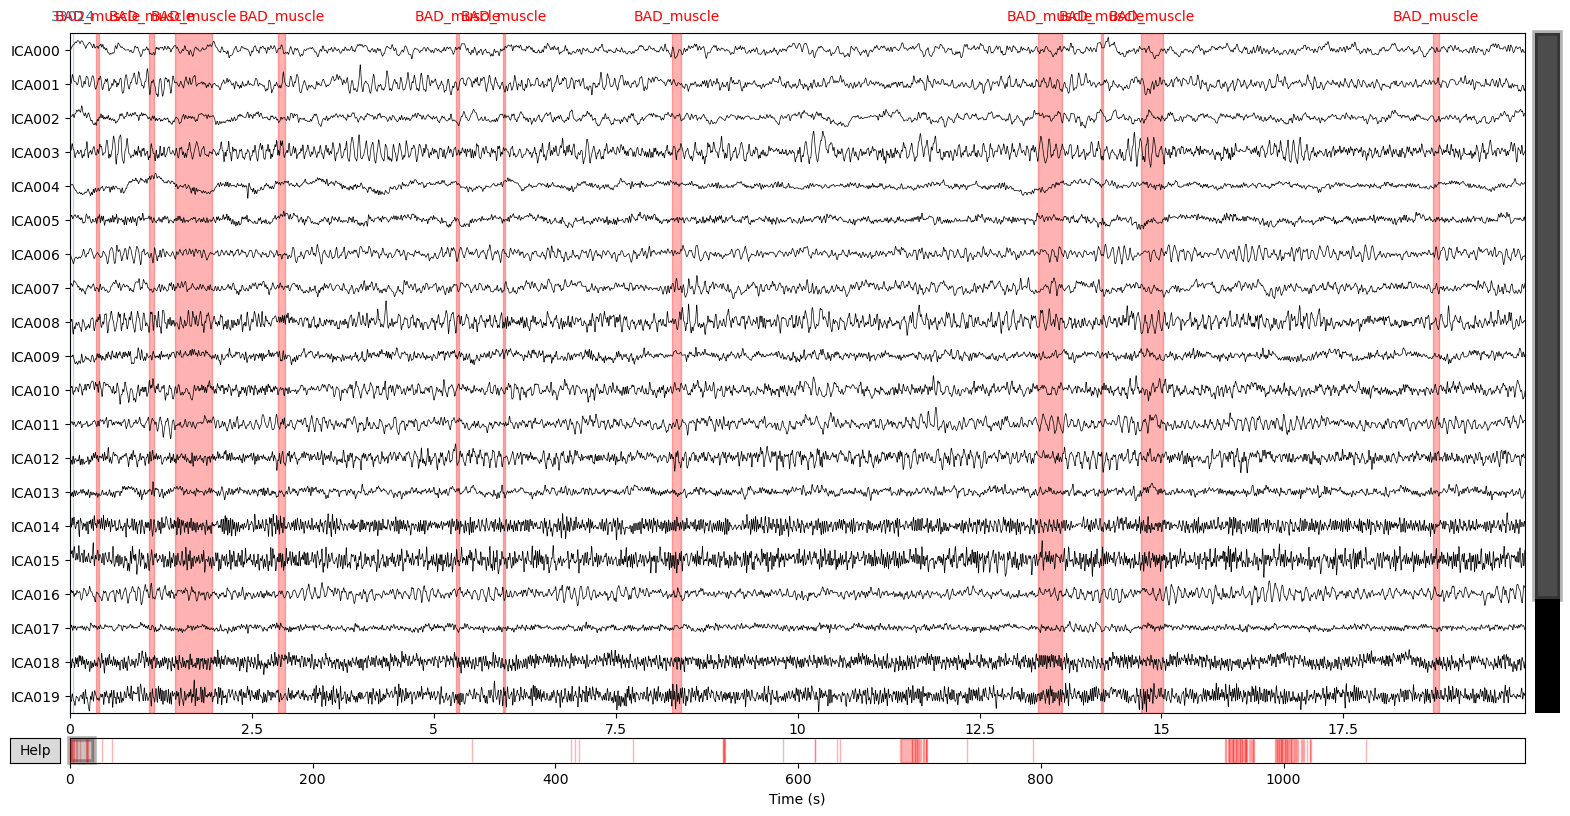

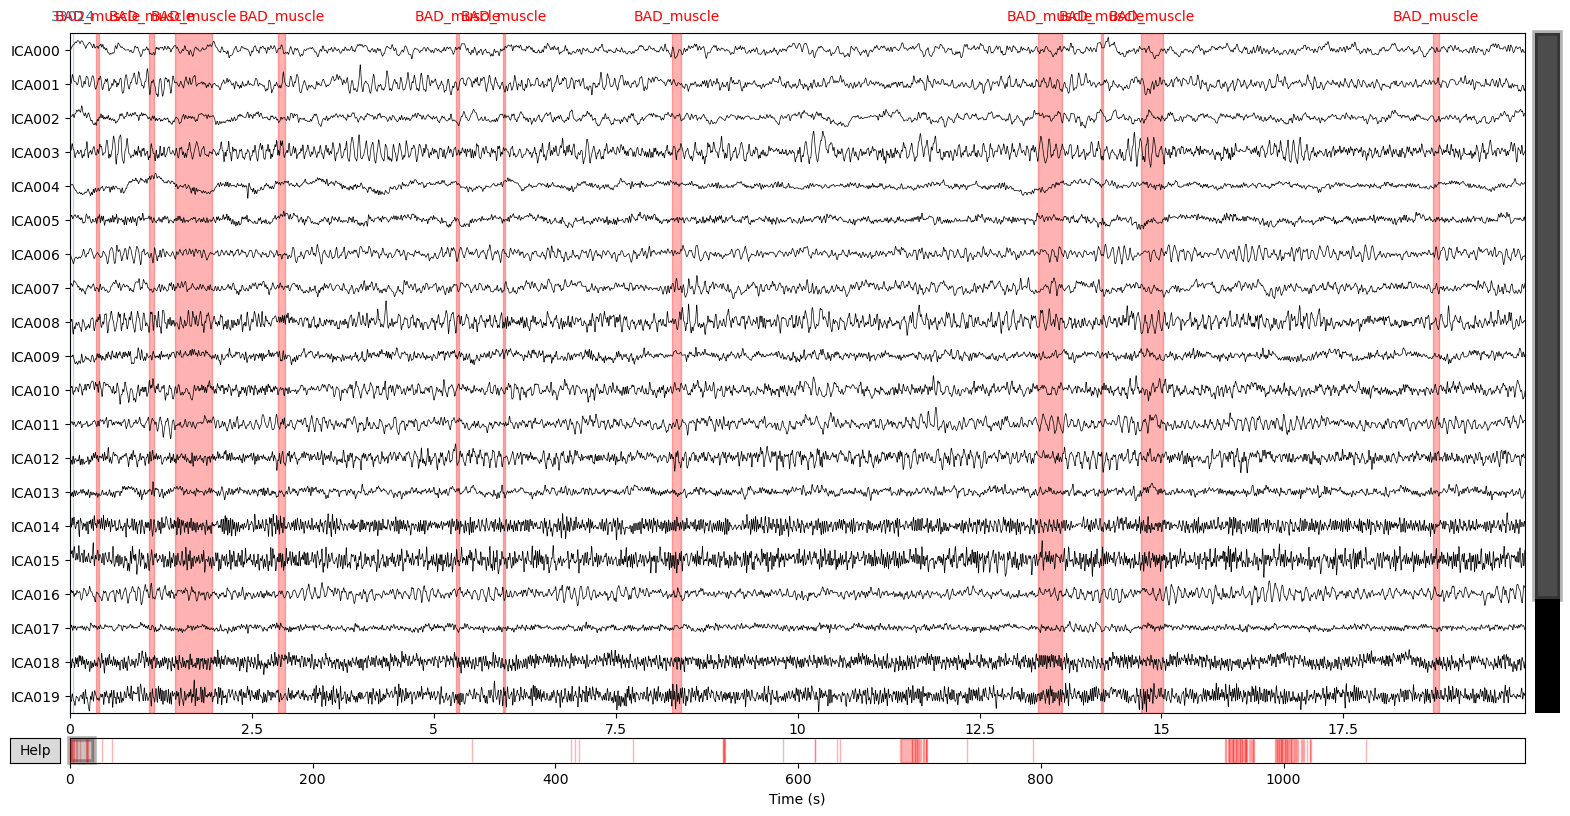

In [13]:
ica.plot_sources(v2,show=False)

In [32]:
cur = ica.apply(v6.copy(),exclude=[5,13,16])

Applying ICA to Raw instance
    Transforming to ICA space (24 components)
    Zeroing out 3 ICA components
    Projecting back using 24 PCA components


In [ ]:
fv1 = cur    # exclude=[13]

In [15]:
fv2 = cur # exclude=[4,5]

In [ ]:
fv3 = cur # exclude=[4,18]

In [ ]:
fv4 = cur # exclude=[3,18, 19]

In [ ]:
fv5 = cur # exclude=[]

In [33]:
fv6 = cur # exclude=[5,13,16]

In [34]:
import pandas as pd


rois = {
    'Frontal': [
        'FP1', 'FP2', 'F3', 'F4', 'F7', 'F8', 'AFZ', 'FZ'
    ],
    
    'Auditory': [
        'T7', 'T8', 'C3', 'C4', 'CZ', 'CPZ'
    ],
    
    'Occipital_Visual': [
        'O1', 'O2', 'POZ', 'PZ'
    ],

    'Gonzalez': [
        'T7', 'T8', 'P8', 'O2', 'F8', 'F7'
    ]
}



def extract_roi_power(clean_raw, participant_id, condition_name):
    segment_duration = 20.0  
    total_duration = clean_raw.times[-1]
    n_segments = int(total_duration // segment_duration)
    
    rows = []
    
    for seg in range(n_segments):
        tmin = seg * segment_duration
        tmax = tmin + segment_duration
        
        # Crop out this 20-second slice of data
        seg_data = clean_raw.copy().crop(tmin=tmin, tmax=tmax, verbose=False)
        
        # Compute PSD
        psd_obj = seg_data.compute_psd(method='welch', fmin=18, fmax=22, n_fft=1024, verbose=False)
        psds, freqs = psd_obj.get_data(return_freqs=True)
        idx_20hz = np.argmin(np.abs(freqs - 20))
        
        global_20hz_power = psds[:, idx_20hz].mean()
        
        for roi_name, channels in rois.items():
            ch_indices = [psd_obj.ch_names.index(ch) for ch in channels if ch in psd_obj.ch_names]
            
            if ch_indices:
                roi_abs_power = psds[ch_indices, idx_20hz].mean()
                roi_relative_power = roi_abs_power / global_20hz_power
                
                rows.append({
                    'Participant': participant_id,
                    'Condition': condition_name,
                    'Segment_ID': seg + 1,  # Tracks the chronological timeline chunks
                    'ROI': roi_name,
                    'abs_power': roi_abs_power,
                    'relative_power': roi_relative_power  
                })
            
    return pd.DataFrame(rows)

# Run the updated pipeline
V01 = extract_roi_power(fv1, participant_id='V01', condition_name='Binaural')
V02 = extract_roi_power(fv2, participant_id='V02', condition_name='Binaural')
V03 = extract_roi_power(fv3, participant_id='V03', condition_name='Binaural')
V04 = extract_roi_power(fv4, participant_id='V04', condition_name='Binaural')
V05 = extract_roi_power(fv5, participant_id='V05', condition_name='Binaural')
V06 = extract_roi_power(fv6, participant_id='V06', condition_name='Binaural')
data_long = pd.concat([V01,V02,V03,V04,V05,V06], ignore_index=True)


/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 1024 is greater than input length  = 410, using nperseg = 410
  return _func(*args, **kwargs)
/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 1024 is greater than input length  = 568, using nperseg = 568
  return _func(*args, **kwargs)
/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 1024 is greater than input length  = 57, using nperseg = 57
  return _func(*args, **kwargs)
/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 1024 is greater than input length  = 91, using nperseg = 91
  return _func(*args, **kwargs)
/Users/johanandersen/miniconda3/envs/mne/lib/python3.14/site-packages/mne/time_frequency/psd.py:291: UserWarning: nperseg = 1024 is 

In [35]:
data_long.to_csv("open_power.csv", index=False)